In [1]:
from dataclasses import asdict
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

# Keep routine progress messages out of the teaching output.
scarf.configure_output(level="WARNING", progress=False)

# Download the prepared example, including its saved analysis.
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq", destination="scarf_datasets", zarr=True
)

In [2]:
# Open the datastore for the following analysis.
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
# Open the saved clustering analysis.
clustering_run = ds.pipeline.open(label="docs_default")
# Keep the graph used by the saved analysis.
graph = clustering_run["connectivity_map"]
# Reuse the saved UMAP coordinates.
umap = clustering_run["umap"]
# Inspect the opened assays and their dimensions.
ds

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

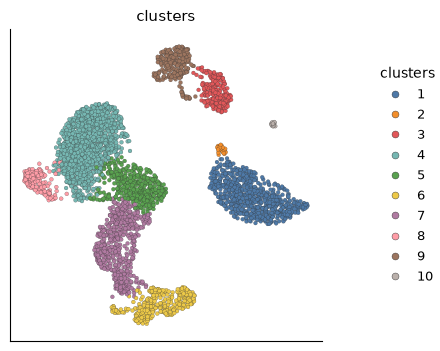

In [3]:
# Inspect the prepared baseline clustering.
ds.plots.embedding(run=clustering_run, color_by="clusters")

In [4]:
# Vary the resolution while keeping the graph unchanged.
leiden_refs = {
    0.3: ds.run_leiden_clustering(graph, resolution=0.3),
    0.5: clustering_run["leiden_0.5"],
    0.8: ds.run_leiden_clustering(graph, resolution=0.8),
}
# Load the labels for each resolution.
leiden_values = {
    resolution: np.asarray(ds.load_artifact(ref)["values"][:])
    for resolution, ref in leiden_refs.items()
}

# Compare cluster sizes across the three Leiden resolutions.
pd.DataFrame(
    {
        resolution: pd.Series(values).value_counts()
        for resolution, values in leiden_values.items()
    }
).fillna(0).astype(int)

,0.3,0.5,0.8
1,716,716,336
2,239,25,377
3,1310,239,28
4,927,1241,239
5,318,434,560
6,142,319,707
7,256,552,289
8,25,151,29
9,15,256,236
10,0,15,309


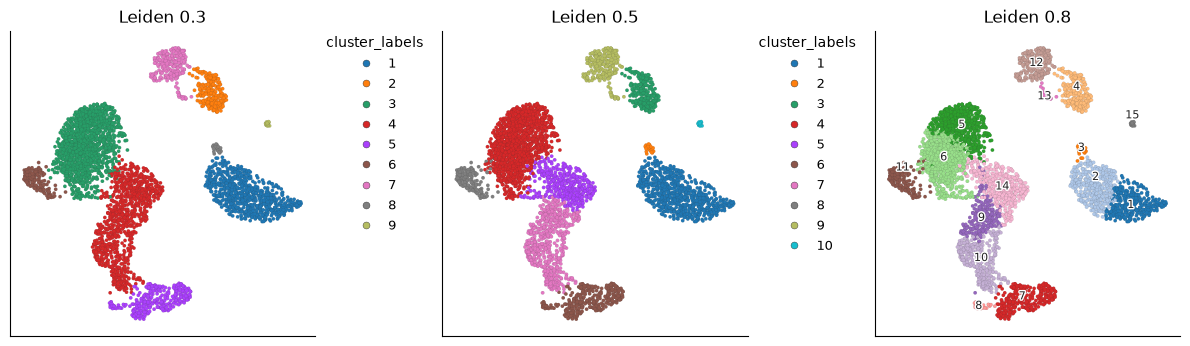

In [5]:
# Create one plotting axis for each comparison panel.
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
# Draw each comparison on its own labeled axis.
for axis, resolution in zip(axes, leiden_values, strict=True):
    # Place this resolution on the common UMAP for comparison.
    ds.plots.embedding(
        layout=umap,
        color_by=leiden_refs[resolution],
        target=axis,
        show_titles=False,
        show=False,
    )
    # Label the panel with the quantity being compared.
    axis.set_title(f"Leiden {resolution}")
# Adjust spacing so panel labels remain readable.
figure.tight_layout()
# Display the completed figure.
figure

In [6]:
# Compare partition agreement for every resolution pair.
pd.Series(
    {
        f"{first} vs {second}": ds.metric_label_concordance(
            leiden_refs[first], leiden_refs[second]
        )
        for first, second in combinations(leiden_refs, 2)
    },
    name="ARI",
)

0.3 vs 0.5    0.870890
0.3 vs 0.8    0.569073
0.5 vs 0.8    0.652480
Name: ARI, dtype: float64

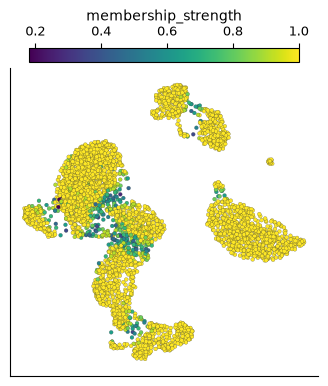

In [7]:
# Inspect the Leiden partition at resolution 0.5.
chosen = leiden_refs[0.5]
# Keep the labels for the partition being reviewed.
chosen_values = leiden_values[0.5]
# Measure each cell's connection to its assigned cluster.
membership = ds.calc_membership_strength(chosen, graph)
# Locate cells with weak or strong cluster membership.
ds.plots.embedding(layout=umap, color_by=membership)

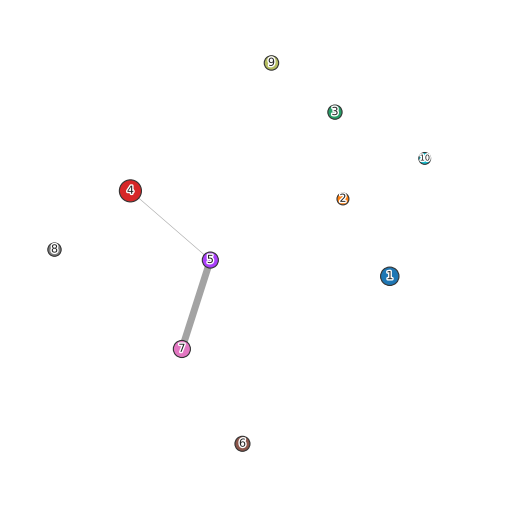

In [8]:
# Show how the chosen clusters connect on this graph.
ds.plots.cluster_connectivity(graph=graph, groups=chosen, layout=umap)

In [9]:
# Keep the marker result for the selected clustering.
markers = ds.run_marker_search(chosen, features=clustering_run["feature_universe"])
# Count the cells in each selected cluster.
sizes = pd.Series(chosen_values).value_counts()
# Identify the most populated cluster.
largest = sizes.index[0]
# Identify the least populated cluster.
smallest = sizes.index[-1]

# Load markers for the largest cluster.
largest_markers = ds.get_markers(marker=markers, group_id=largest)
# Load markers for the smallest cluster.
smallest_markers = ds.get_markers(marker=markers, group_id=smallest)
# Identify the largest and smallest clusters being compared below.
pd.Series({"largest cluster": largest, "smallest cluster": smallest})

largest cluster      4
smallest cluster    10
dtype: int64

In [10]:
# Inspect the leading markers for the largest cluster.
marker_columns = ["feature_name", "score", "auc", "p_value", "p_value_adjusted"]
# Preview these statistics for the ten leading markers.
largest_markers[marker_columns].head(10)

,feature_name,score,auc,p_value,p_value_adjusted
0,ADTRP,0.61890,0.60920,3.580369e-108,6.286828e-106
1,FHIT,0.51857,0.77473,3.305650e-282,3.695496e-279
2,TSHZ2,0.48540,0.63679,6.612532e-118,1.327971e-115
3,TCEA3,0.48253,0.59006,2.671241e-75,2.509470e-73
4,CHRM3-AS2,0.46413,0.66321,7.806746e-146,2.218836e-143
5,CMTM8,0.43859,0.61914,1.037609e-85,1.298483e-83
6,EPHX2,0.43070,0.66277,6.659238e-138,1.731299e-135
7,MAN1C1,0.42497,0.62275,2.670897e-85,3.293256e-83
8,NOG,0.42190,0.61849,1.471531e-118,2.973024e-116
9,LRRN3,0.39995,0.73614,9.865691e-246,7.519899e-243


In [11]:
# Inspect the leading markers for the smallest cluster.
smallest_markers[marker_columns].head(10)

,feature_name,score,auc,p_value,p_value_adjusted
0,TPM2,0.83726,0.96477,7.923809e-68,2.438062e-65
1,SERPINF1,0.82985,0.99685,1.200639e-123,6.711172e-121
2,MAP1A,0.81256,0.96035,2.330331e-109,1.070611e-106
3,LILRA4,0.81141,0.99976,2.403755e-215,2.303346e-212
4,IL3RA,0.80536,1.00000,9.536887e-170,7.269275e-167
5,SMPD3,0.79616,0.99775,2.867716e-210,2.671596e-207
6,DNASE1L3,0.79286,0.99868,6.656585e-193,5.874962e-190
7,GAS6,0.78312,0.99888,3.028428e-271,5.078371e-268
8,DERL3,0.77951,0.96440,1.351287e-130,8.092761e-128
9,FCER1A,0.76586,0.82674,6.683680e-63,1.949194e-60


In [12]:
# Choose an adaptive cut of the Paris hierarchy.
paris_auto = ds.run_paris_clustering(graph)
# Load the Paris labels and hierarchy diagnostics.
paris_result = ds.load_paris_clustering(paris_auto)
# Inspect the size and persistence of each selected Paris group.
pd.DataFrame([asdict(item) for item in paris_result.diagnostics])[
    ["label", "size", "persistence", "decision_margin", "forced"]
]

,label,size,persistence,decision_margin,forced
0,1,381,87.005282,0.106567,False
1,2,332,75.167770,0.066890,False
2,3,228,144.527046,0.560474,False
3,4,1339,430.260234,0.165564,False
4,5,284,62.717847,NaN,False
5,6,332,114.578882,0.171068,False
6,7,143,105.512744,0.649577,False
7,8,267,53.963308,NaN,False
8,9,570,109.741983,NaN,False
9,10,28,21.267540,NaN,False


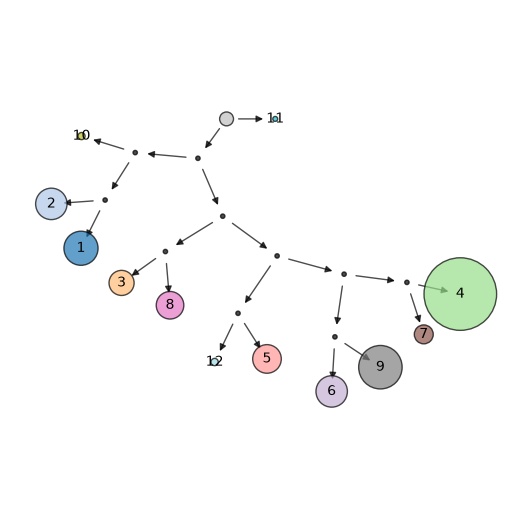

In [13]:
# Show the hierarchy supporting the Paris partition.
ds.plots.cluster_tree(graph=graph, clusters=paris_auto)

In [14]:
# Cut the same hierarchy at the adaptive result's cluster count.
paris_fixed = ds.run_paris_clustering(graph, n_clusters=paris_result.n_clusters)
# Compare the adaptive Paris cut with fixed Paris and Leiden partitions.
pd.Series(
    {
        "auto vs fixed ARI": ds.metric_label_concordance(paris_auto, paris_fixed),
        "Leiden vs Paris ARI": ds.metric_label_concordance(chosen, paris_auto),
    }
)

auto vs fixed ARI      0.943232
Leiden vs Paris ARI    0.791518
dtype: float64